This notebook covers:
- Neural Network Fundamentals
- Backpropagation (from scratch)
- ANN implementation
- Computer Vision & CNN
- Transfer Learning
- MNIST Digit Classification

## 1. Introduction to Deep Learning

Deep Learning is a subset of Machine Learning that uses neural networks with multiple layers to learn patterns from data. It is widely used in image recognition, NLP, and speech processing.

## 2. Neural Network Fundamentals

### Neuron
A neuron takes input values, applies weights and bias, and passes the result through an activation function.

### Perceptron
A perceptron is the simplest type of neural network used for binary classification.

### Neural Network
A neural network consists of layers:
- Input Layer
- Hidden Layer(s)
- Output Layer

## 3. Backpropagation 

Backpropagation is used to train neural networks by updating weights using the error.

Steps:
1. Forward pass
2. Calculate loss
3. Backward pass (compute gradients)
4. Update weights

In [1]:
import numpy as np

# Dataset (XOR problem)
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[1],[1],[0]])

# Initialize weights
np.random.seed(1)
weights = np.random.rand(2,1)
bias = np.random.rand(1)

# Sigmoid function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Training loop
for i in range(1000):
    z = np.dot(X, weights) + bias
    output = sigmoid(z)

    error = y - output
    weights += np.dot(X.T, error) * 0.1

print("Trained Weights:\n", weights)

Trained Weights:
 [[-7.62498798e-05]
 [-7.62498767e-05]]


## 4. Artificial Neural Network (ANN)

An ANN consists of multiple layers where each neuron is connected to others.

Training involves:
- Forward propagation
- Loss calculation
- Backpropagation

## 5. Data Preprocessing & Feature Engineering

Data preprocessing improves model performance.

Common steps:
- Normalization
- Feature scaling
- Handling missing values

In [2]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled Data:\n", X_scaled)

Scaled Data:
 [[-1. -1.]
 [-1.  1.]
 [ 1. -1.]
 [ 1.  1.]]


## 6. Computer Vision Basics

Computer Vision allows machines to interpret images.

Images are represented as pixel values. CNNs help extract important features automatically.

## 7. Convolutional Neural Networks (CNN)

### Convolution Layer
Extracts features using filters.

### Pooling Layer
Reduces image size and computation.

CNNs are widely used for image classification tasks.

In [4]:
from tensorflow.keras import layers, models

cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

cnn_model.summary()

c:\Users\HP\GDGOC-Atk-AI-ML-Fellowship\myenv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       346,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 347,146 (1.32 MB)

 Trainable params: 347,146 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

## 8. Transfer Learning

Transfer learning uses pretrained models to solve new problems.

It saves time and improves accuracy.

In [6]:
from tensorflow.keras.applications import VGG16

base_model = VGG16(weights='imagenet', include_top=False)

print("Pretrained model loaded successfully")

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 357s 6us/step
Pretrained model loaded successfully


## 9. MNIST Digit Classification

I will build a neural network to classify handwritten digits using the MNIST dataset.

In [7]:
import tensorflow as tf
from tensorflow.keras import datasets

(X_train, y_train), (X_test, y_test) = datasets.mnist.load_data()

print("Training data shape:", X_train.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 66s 6us/step
Training data shape: (60000, 28, 28)


In [8]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [9]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Flatten(input_shape=(28,28)),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

c:\Users\HP\GDGOC-Atk-AI-ML-Fellowship\myenv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [10]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [11]:
model.fit(X_train, y_train, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - accuracy: 0.9283 - loss: 0.2541
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step - accuracy: 0.9679 - loss: 0.1095
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9772 - loss: 0.0765
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - accuracy: 0.9826 - loss: 0.0563
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - accuracy: 0.9865 - loss: 0.0441


In [12]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9762 - loss: 0.0728


[0.07280194014310837, 0.9761999845504761]

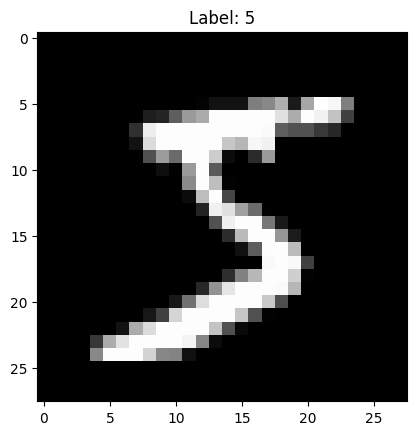

In [13]:
import matplotlib.pyplot as plt

plt.imshow(X_train[0], cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.show()

## 10. Conclusion

In this task, I learned:
- Neural Network basics
- Backpropagation
- CNN concepts
- Transfer learning
- Built an MNIST classifier

Neural Networks are powerful tools for solving complex real-world problems, especially in Computer Vision.